In [45]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Filter for Data Scientist data
df_DE = df[df['job_title_short'] == 'Data Engineer'].copy()


In [46]:
df_DE

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
7,Data Engineer,Data Engineer,Anywhere,via LinkedIn,Full-time,True,Romania,2023-12-07 13:40:49,False,False,Romania,NaN,NaN,NaN,Zitec,"[sql, nosql, gcp, azure, aws, bigquery, databr...","{'cloud': ['gcp', 'azure', 'aws', 'bigquery', ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785729,Data Engineer,Data Engineer Marketing Intelligence,Jerman,melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,IU Internationale Hochschule,NaN,NaN
785730,Data Engineer,"Data Center Engineering Operations Engineer , ...","Bangkok, Thailand",melalui LinkedIn,Pekerjaan tetap,False,Thailand,2023-03-12 06:37:47,False,False,Thailand,NaN,NaN,NaN,Amazon Web Services (AWS),"[excel, word, outlook]","{'analyst_tools': ['excel', 'word', 'outlook']}"
785731,Data Engineer,Data Engineer,"Overland Park, Kansas, Amerika Serikat",melalui LinkedIn,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:17,False,False,Sudan,NaN,NaN,NaN,Shamrock Trading Corporation,"[nosql, mongodb, mongodb, python, elasticsearc...","{'analyst_tools': ['excel'], 'cloud': ['aws', ..."
785732,Data Engineer,Data Engineer (f/m/d),"Heidelberg, Jerman",melalui Top County Careers,Pekerjaan tetap,False,Germany,2023-03-13 06:18:59,False,False,Germany,NaN,NaN,NaN,Heidelberg Materials,"[python, c#, java, scala, sql, postgresql, sql...","{'cloud': ['azure', 'databricks'], 'databases'..."


In [47]:
df_DE = df[df['job_title_short'] =='Data Engineer']


In [48]:
# Cell 2 - Explode skills and create pivot ✅
df_DE_exploded = df_DE.explode('job_skills')

df_DE_pivot = df_DE_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
).reset_index()

df_DE_pivot.sort_values(by='skill_count', ascending=False, inplace=True)

In [49]:
df_DE_pivot

,job_skills,skill_count,median_salary
194,sql,113130,125000.0
159,python,108022,125000.0
15,aws,62049,130000.0
16,azure,60674,125000.0
189,spark,53656,134775.0
...,...,...,...
87,homebrew,3,96773.0
11,asp.netcore,2,NaN
105,linode,1,NaN
26,chainer,1,NaN


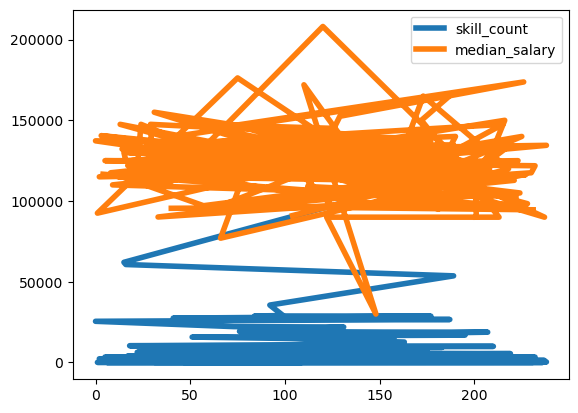

In [50]:
df_DE_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth = 4)
plt.show()

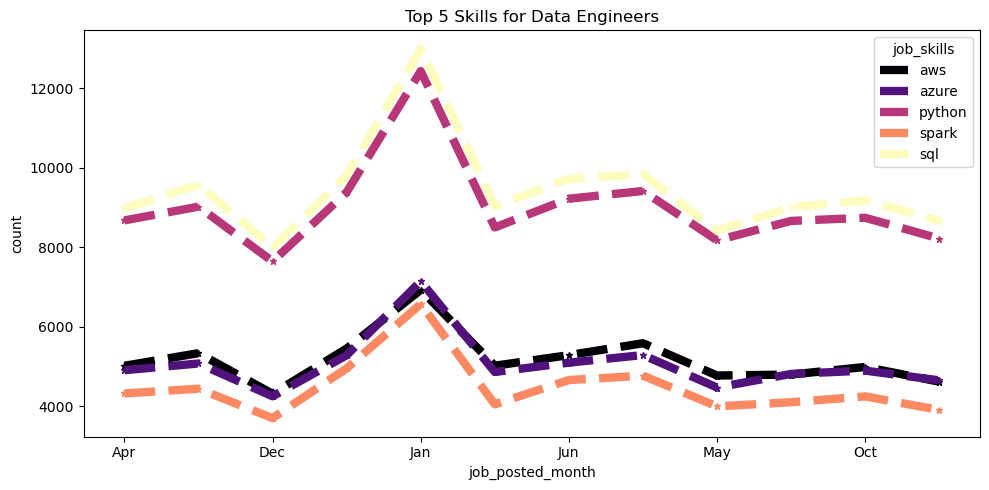

In [51]:
# Step 1 - Prepare the data
df_DE_exploded = df_DE.explode('job_skills')

# Step 2 - Get top 5 skills
top_5_skills = df_DE_exploded['job_skills'].value_counts().head(5).index.tolist()

# Step 3 - Filter and create pivot
df_DE_pivot = df_DE_exploded[df_DE_exploded['job_skills'].isin(top_5_skills)]

df_DE_pivot = df_DE_pivot.groupby(
    [df_DE_pivot['job_posted_date'].dt.strftime('%b'), 'job_skills']
)['job_skills'].count().unstack()

# Step 4 - Plot like the right graph
df_DE_pivot.plot(
    kind='line',
    linewidth=6,
    linestyle='--',
    colormap='magma',
    marker='*',
    markersize=5,
    figsize=(10, 5)
)

plt.xlabel('job_posted_month')
plt.ylabel('count')
plt.title('Top 5 Skills for Data Engineers')
plt.legend(title='job_skills')
plt.tight_layout()
plt.show()

In [54]:
# Explode the 'job_skills' into individual rows
df_exploded = df_DE.explode('job_skills')

# Calculate the average salary and count of job postings per skill
skill_stats = df_exploded.groupby('job_skills').agg(  # ✅ dot not comma
    median_salary=('salary_year_avg', 'median'),
    skill_count=('job_skills', 'count')
)

# Limit to the top skills
skill_count = 20
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(skill_count)

skill_stats


,median_salary,skill_count
job_skills,,
sql,125000.0,113130
python,125000.0,108022
aws,130000.0,62049
azure,125000.0,60674
spark,134775.0,53656
java,134241.0,35559
kafka,140000.0,29073
hadoop,134241.0,28815
scala,137500.0,28716


In [66]:
from adjustText import adjust_text

skill_stats.plot(kind='scatter', x= 'skill_count', y='median_salary', figsize-(10,6))

texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i],skill_stats['median_salary'].iloc[i], txt))
plt.show()

adjust_text(texts
        arrowprops=dict(arrowstyle='->',color='gray'))

plt.xlabel('Count of DE JPO')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs.Count of Job Postings for Top 10 Skills')
plt.tight_layout()

plt.show()

SyntaxError: positional argument follows keyword argument (2745738083.py, line 3)

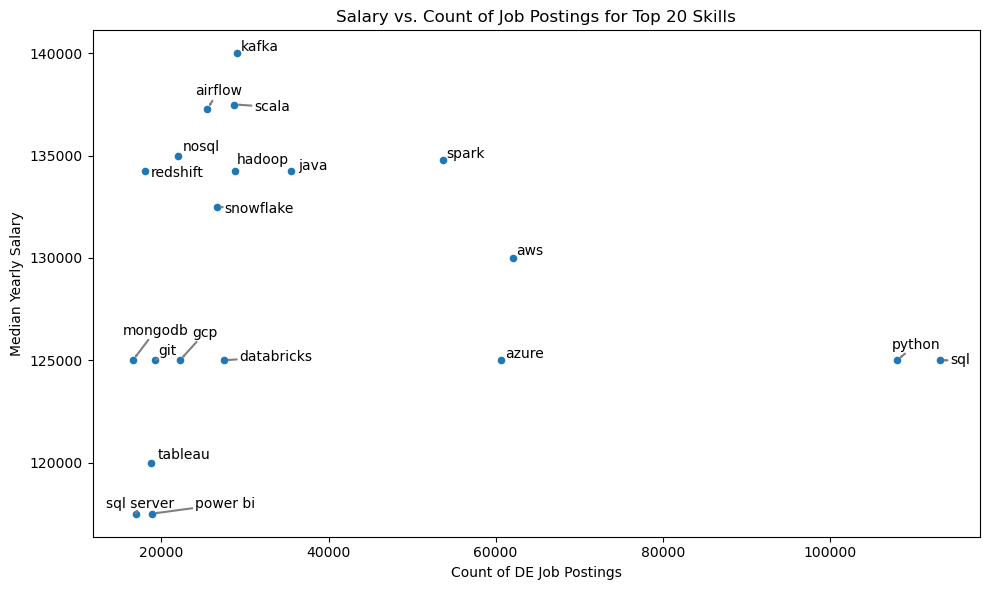

In [69]:

from adjustText import adjust_text

# Step 1 - Create plot
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary', figsize=(10, 6))

# Step 2 - Add skill name labels ✅
texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(
        skill_stats['skill_count'].iloc[i],
        skill_stats['median_salary'].iloc[i],
        txt  # ← this is the skill name e.g. 'python', 'sql'
    ))

# Step 3 - Prevent overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Step 4 - Labels and title
plt.xlabel('Count of DE Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs. Count of Job Postings for Top 20 Skills')
plt.tight_layout()
plt.show()


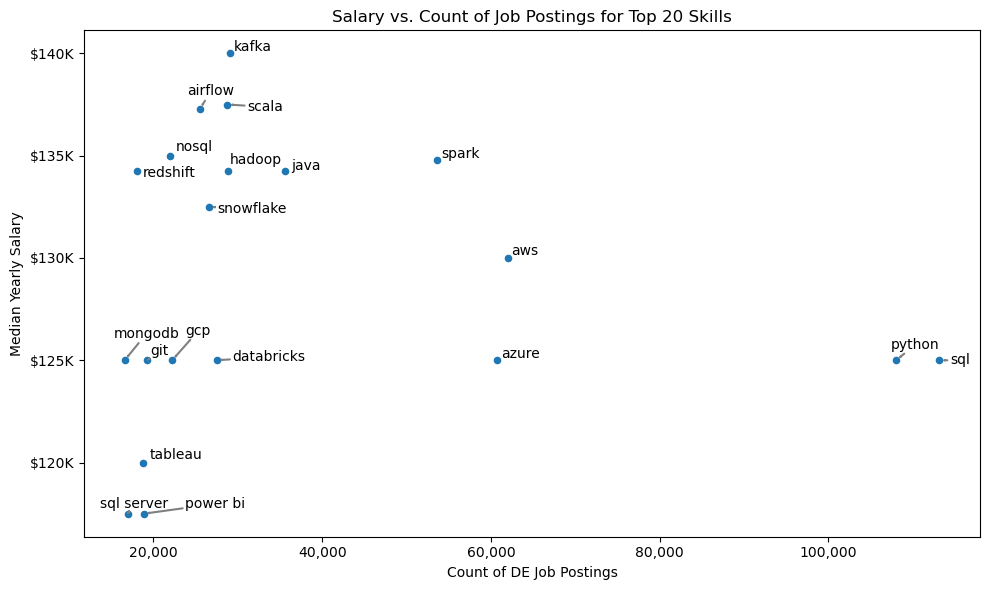

In [77]:
fig, ax = plt.subplots(figsize=(10, 6))


from adjustText import adjust_text

# Step 1 - Create plot
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary',ax=ax, )

texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(ax.text(
        skill_stats['skill_count'].iloc[i],
        skill_stats['median_salary'].iloc[i],
        txt  # ← this is the skill name e.g. 'python', 'sql'
    ))

# Step 3 - Prevent overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax = plt.gca() 
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
import matplotlib.ticker as mticker
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))  # ✅ adds commas

# Step 4 - Labels and title
plt.xlabel('Count of DE Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs. Count of Job Postings for Top 20 Skills')
plt.tight_layout()
plt.show()
